### **Project : Student Pass/Fail Prediction**
### **Algorithm : ID3 (Decision Tree Classifier)**

In [1]:
# Step No 1 : Importing Required Libraries 

# Import numerical library
import numpy as np 

# Import Manupulation and Data Cleaning library 
import pandas as pd 

# Import Plotting library 
import matplotlib.pyplot as plt 

# Import Seaborn library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Label Encoder 
from sklearn.preprocessing import LabelEncoder

# Import Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier

# Import Evaluation Metrics 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [4]:
# Step NO 2 : Load Dataset 
df = pd.read_csv("StudentsPerformance.csv")

In [5]:
# Step No 3 : Data Understanding 

# Display first rows 
print(df.head())

# Display shape 
print(df.shape)

# Display dataset information 
print(df.info())

# Display statistical summary
print(df.describe())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null C

In [6]:
# Step No 4 : Data Cleaning 

# Check missing values 
print(df.isnull().sum())

# Fill Missing Values 
df.fillna(df.mode().iloc[0],
          inplace=True)

# Check duplicate rows 
print(df.duplicated().sum())

# Remove duplicates 
df = df.drop_duplicates()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
0


In [7]:
# Step No 5 : Create Target Variable 

# Create Pass / Fail Column 
df["Pass_Fail"] = np.where(
    df["math score"] >= 50 , 
    1,
    0
)

In [8]:
# Step No 6 : Encode Categorical Data 

# Create Label Encoder Object 
encoder = LabelEncoder()

# Encode Categorical Column 
for column in df.columns:
    
    if df[column].dtype == "object":
        
        df[column] = encoder.fit_transform(
            df[column]
        )

In [9]:
# Step No 7 : Features and Target 

# Define input features 
X = df.drop(
    columns=["Pass_Fail"]
)

# Define target variable 
y = df["Pass_Fail"]

<function matplotlib.pyplot.show(close=None, block=None)>

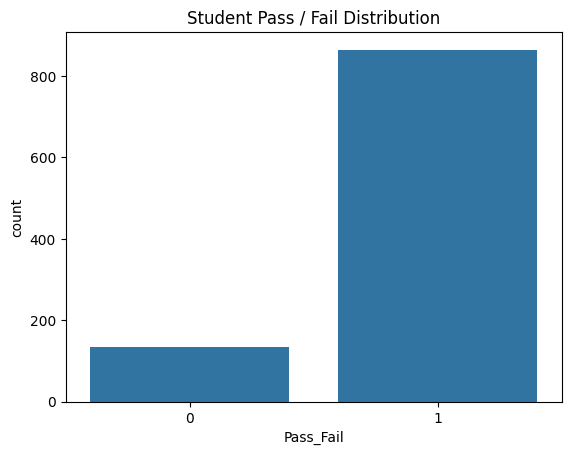

In [10]:
# Step No 8 : Visualization 

# Create Countplot 
sns.countplot(
    x = "Pass_Fail",
    data=df
)
# Set title 
plt.title("Student Pass / Fail Distribution")

# Display Plot 
plt.show 

In [11]:
# Step No 9 : Train Test Split 

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= 42 
)

In [12]:
# Step No 10 : Create ID3 Model 
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth= 5 ,
    random_state= 42
)

In [13]:
# Step No 11 : Train Model 
model.fit(X_train , y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [14]:
# Step No 12 : Prediction 
y_pred = model.predict(
    X_test
)

# Display the predicated value 
print("Predicted Values : ")
print(y_pred)

Predicted Values : 
[1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 0 0 1 1 1 0 0 0 1 1 1 1 1 0 1
 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 1 1
 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1]


In [15]:
# Step No 13 : Evaluation Metrics 
# Accuracy Evaluation 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred))

# Classification Report 
print("Classification Report : ")
print(classification_report(y_test , y_pred ))

# Confusion Matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred ))

Accuracy Score : 
1.0
Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00       166

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix : 
[[ 34   0]
 [  0 166]]


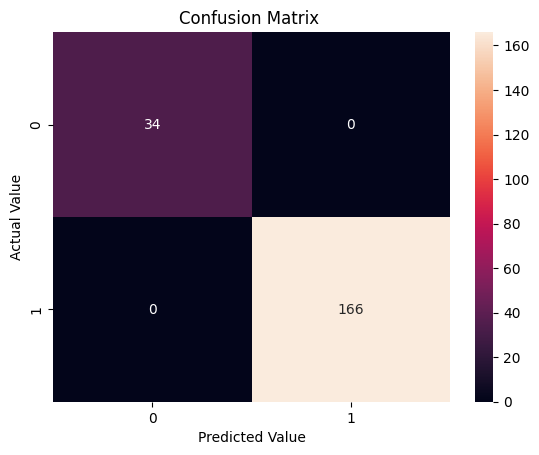

In [16]:
# Step No 14 : Confusion Matrix Visualization 
sns.heatmap(confusion_matrix(y_test , y_pred) , annot= True , fmt = "d")

# Set the title 
plt.title("Confusion Matrix ")

# Set Xlabel
plt.xlabel("Predicted Value")

# Set Ylabel 
plt.ylabel("Actual Value")

# Display the Output 
plt.show()

In [17]:
# Step No 15 : Feature Importance 
feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance": model.feature_importances_
})
print(feature_importance)

                       Feature  Importance
0                       gender         0.0
1               race/ethnicity         0.0
2  parental level of education         0.0
3                        lunch         0.0
4      test preparation course         0.0
5                   math score         1.0
6                reading score         0.0
7                writing score         0.0


In [18]:
# Step No 16 : User Input 
print("\nEnter Student Information \n")

gender = int(input("Gender : "))

race = int(input("Race/ Ethnicity : "))

education = int(input("Parental Education : "))

lunch = int(input("Lunch : "))

test_course = int(input("Test Preparation Course : "))

math_score = float(input("Math Score : "))

reading_socre = float(input("Reading Score : "))

writing_score = float(input("Writing Score : "))


Enter Student Information 



In [19]:
# Step No 17 : Create User DataFrame 

user_data = pd.DataFrame({
    "gender": [gender],
    
    "race/ethnicity":[race],
    
    "parental level of education":[education],
    
    "lunch":[lunch],
    
    "test preparation course":[test_course],
    
    "math score": [math_score],
    
    "reading score": [reading_socre],
    
    "writing score":[writing_score]
})

In [20]:
# Step No 18 : Final Prediction 
result = model.predict(user_data)

if result[0] == 1 :
    print("Student Pass")
else:
    print("Student Fail")

Student Fail
